In [1]:
# 필요한 라이브러리 호출
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
import os
PATH = os.getcwd()
print(PATH)

/Users/janghyoin/Desktop/2025/Euron/예습 과제/Week3


In [3]:
# GPU 사용 권장, 설치되지 않았을 경우 CPU 사용
device = torch.device("mps" if torch.mps.is_available() else "cpu")

In [4]:
# 데이터셋 다운로드 받기
train_dataset = torchvision.datasets.FashionMNIST('data', download = True, 
                                                 transform=transforms.Compose([transforms.ToTensor()]))


test_dataset = torchvision.datasets.FashionMNIST('data', download = True, train = False,
                                                 transform=transforms.Compose([transforms.ToTensor()]))

- `torchvision.datasets`은 `torch.utils.data.Datasets`의 하위 클래스로 다양한 데이터셋을 포함함. 
- `torchvision.datasets.FashionMNIST('data', download = True, train = False,
                                    transform=transforms.Compose([transformsToTensor()]))`
    - `'data'`: 데이터셋을 내려받을 위치
    - `downlaod`: 첫번째 파라미터의 위치에 해당 데이터셋이 있는지 확인 후, 내려받음
    - `transform`: 이미지를 텐서(0~1)로 변경

내려받은 데이터를 메모리로 불러오기 위해 **데이터로더**에 전달

In [6]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

- `torch.utils.data.DataLoader(train_dataset, batch_size = 100)` 을 사용해 
원카는 크기의 배치 단위로 데이터를 불러오거나, 순서가 무작위로 섞이도록 할 수 있음
    - `train_dataset`: 데이터를 불러올 데이터셋을 지정
    - `batch_size`: 데이터를 배치로 묶어줌 (100개 단위로 데이터를 묶어서 불러옴)

In [7]:
# 분류에 사용될 클래스 정의
labels_map = {
    0 : 'T-Shirt',
    1 : 'Trouser',
    2 : 'Pullover',
    3 : 'Dress',
    4 : 'Coat',
    5 : 'Sandal',
    6 : 'Shirt',
    7 : 'Sneaker',
    8 : 'Bag',
    9 : 'Ankle Boot'
}

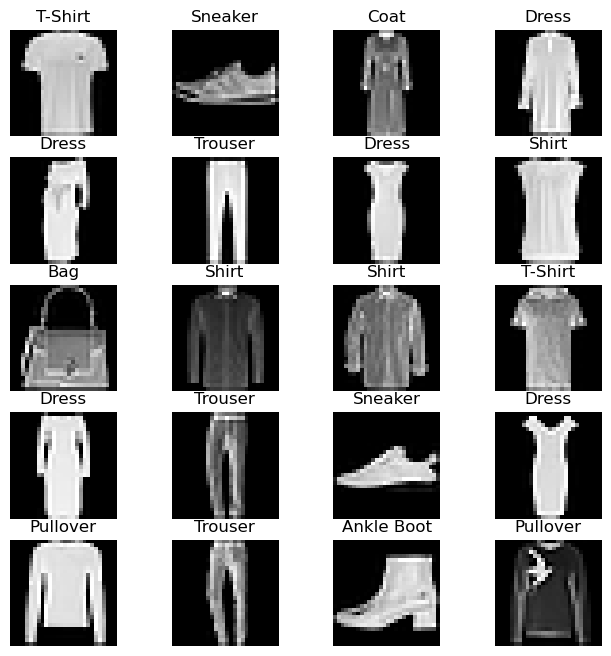

In [8]:
fig = plt.figure(figsize=(8, 8))
columns = 4
rows = 5
for i in range(1, columns * rows + 1):
    img_xy = np.random.randint(len(train_dataset)) # 0~train_dataset 길이 중 랜덤한 숫자 한 개 생성
    img = train_dataset[img_xy][0][0,:,:] # train_dataset을 이용한 3차원 배열 생성
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

**심층 신경망 모델 생성**

In [13]:
class FashionDNN(nn.Module):
    def __init__(self):
        super(FashionDNN, self).__init__()
        self.fc1 = nn.Linear(in_features=784, out_features=256)
        # in_features: 입력 크기
        # out_features: 출력 크기
        self.drop = nn.Dropout(0.25) # 전체 값 중 0.25의 확률로 0이 되고, 그렇지 않은 값은 4/3만큼 커짐
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)
    
    def forward(self, input_data): # 모델이 학습 데이터를 입력 받아서 순전파 학습을 진행
        # nn.Linear의 첫 번째 파라미터를 입력받음
        out = input_data.view(-1, 784) # 텐서를 2차원 (?, 784)의 크기로 변경 
        out = F.relu(self.fc1(out)) # forward() 함수에서 정의
        out = self.drop(out) # __init__ 함수에서 정의
        out = F.relu(self.fc2(out))
        out = self.fc3(out)
        return out # nn.Linear의 두 번째 파라미터 출력

- `F.xx()` (`nn.functional.xx()`)와 `nn.xx()` 차이 비교

In [10]:
# nn.Fucntional 사용
import torch.nn.functional as F

inputs = torch.randn(64, 3, 244, 244) # 평균이 0이고 표준편차가 1인 정규분포를 따르는 랜덤 값들로 구성된 텐서를 생성
#  텐서의 크기가 (64, 3, 244, 244)
# 64: batch size (한 번에 64개 이미지 처리), 3: 채널수, (244, 244): (H, W)
weight = torch.randn(64, 3, 3, 3) 
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight, bias, padding = 1)

- 입력과 가중치 자체를 직접 넣어야하며, 가중치를 전달할 때마다 가중치 값을 새로 정의해야함
- 함수를 호출할 때 하이퍼 파라미터와 데이터 전달

In [11]:
# nn 사용
import torch
import torch.nn as nn
inputs = torch.randn(64, 3, 244, 244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
# 3 개의 채널이 입력되어 64 개의 채널이 출력되기 위한 연산 (3*3 크기의 커널 사용)
outputs = conv(inputs) # 함수 호출 후 데이터 전달
layer = nn.Conv2d(1, 1, 3)

- 먼저 하이퍼 파라미터를 전달한 후 함수 호출을 통해 데이터 전달
- 파라미터 새로 정의할 필요 x

**파라미터 정의**

In [14]:
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss() # 손실함수 정의
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


**모델 학습**

In [15]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train) # 훈련 데이터로 모델 학습
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward() # 역전파 계산
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(count)
            accuracy_list.append(accuracy)
        
        if not (count%500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5958743095397949, Accuracy: 83.2300033569336%
Iteration: 1000, Loss: 0.48090147972106934, Accuracy: 84.18000030517578%
Iteration: 1500, Loss: 0.3547356426715851, Accuracy: 84.77999877929688%
Iteration: 2000, Loss: 0.36035120487213135, Accuracy: 85.5%
Iteration: 2500, Loss: 0.2728109061717987, Accuracy: 86.27999877929688%
Iteration: 3000, Loss: 0.2886870503425598, Accuracy: 86.41999816894531%


**합성곱 네트워크 생성**

In [16]:
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc1 = nn.Linear(in_features=64 * 6* 6, out_features=600)
        self.drop = nn.Dropout2d(0.25)
        self.fc2 = nn.Linear(in_features=600, out_features=120)
        self.fc3 = nn.Linear(in_features=120, out_features=10)
    
    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)
        out = self.fc1(out)
        out = self.drop(out)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

**합성곱 네트워크를 위한 파라미터 정의**

In [17]:
learning_rate = 0.001
model = FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


**모델 학습 및 성능 평가**

In [18]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        train = Variable(images.view(100, 1, 28, 28))
        labels = Variable(labels)

        outputs = model(train)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        count += 1

        if not (count % 50):
            total = 0
            correct = 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                labels_list.append(labels)
                test = Variable(images.view(100, 1, 28, 28))
                outputs = model(test)
                predictions = torch.max(outputs, 1)[1].to(device)
                predictions_list.append(predictions)
                correct += (predictions == labels).sum()
                total += len(labels)

            accuracy = correct * 100 / total
            loss_list.append(loss.data)
            iteration_list.append(count)
            accuracy_list.append(accuracy)
        
        if not (count % 500):
            print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/opt/anaconda3/envs/euron/lib/python3.9/site-packages/torch/nn/functional.py:1538: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Iteration: 500, Loss: 0.4630039930343628, Accuracy: 87.37999725341797%
Iteration: 1000, Loss: 0.30371615290641785, Accuracy: 87.44999694824219%
Iteration: 1500, Loss: 0.3135014772415161, Accuracy: 87.95999908447266%
Iteration: 2000, Loss: 0.22828266024589539, Accuracy: 89.52999877929688%
Iteration: 2500, Loss: 0.13720618188381195, Accuracy: 89.66999816894531%
Iteration: 3000, Loss: 0.15184128284454346, Accuracy: 90.22000122070312%


심층 신경망과 비교하여 정확도가 약간 더 높음 (약 4%). 심층 신경망과 큰 차이는 없지만, 이미지 데이터가 많아지면 단순 심층 신경망으로는 정확한 특성 추출 및 분류가 불가능 하므로 학습 신경망을 생성하는 연습이 필요